# Technology for Energy systems integration - Final Assignment
## Energy transition study with integration of multiple energy carriers

POINT 2: Design for zero emission energy system with integration of multiple energy carriers, including electricity, heat and hydrogen, for given demand and constraints

In [1]:
import pandas as pd
import numpy as np
import requests
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pvlib


In [2]:
# Student specific given information:
node_lat = 54.6172
node_lon = 9.5776
node_alt = 0

distance12 = 53 #km
distance23 = 89 #km

electricity_demand_multiplier = .54
heat_demand_multiplier = .43
hydrogen_demand_multiplier = .48
hydrogen_production_multiplier = .45


In [3]:
# Create time series with hourly resolution for given period
year = 2009
month = 2
times = pd.date_range(start='2009-02-01', end='2009-02-28 23:59:59', freq='h', tz='Europe/Amsterdam')

In [4]:
# Function to import climate data from JRC - DO NOT CHANGE

def import_jrc_climate_data(lon: float, lat: float, year: int | str, alt: float) -> dict:
    """
    Reads in climate data for a full year from `JRC PVGIS <https://re.jrc.ec.europa.eu/pvg_tools/en/>`_.

    :param float lon: longitude of node - the api will read data for this location
    :param float lat: latitude of node - the api will read data for this location
    :param int year: optional, needs to be in range of data available. If nothing is specified, a typical year \
    will be loaded
    :param float alt: altitude of location specified
    :return: dict containing information on the location (altitude, longitude, latitude and a dataframe \
    containing climate data (ghi = global horizontal irradiance, dni = direct normal irradiance, \
    dhi = diffuse horizontal irradiance, rh = relative humidity, temp_air = air temperature, ws = wind speed at \
    specified hight. Wind speed is returned as a dict for different heights.
    :rtype: dict
    """

    # Specify year import, lon, lat
    parameters = {"lon": lon, "lat": lat, "year": year, "outputformat": "json"}
    time_index = pd.date_range(
        start=str(year) + "-01-01 00:00", end=str(year) + "-12-31 23:00", freq="1h"
    )

    # Get data from JRC dataset
    answer = dict()
    print("Importing Climate Data...")
    response = requests.get("https://re.jrc.ec.europa.eu/api/tmy?", params=parameters)
    if response.status_code == 200:
        print("Importing Climate Data successful")
    else:
        raise Exception(response)
    data = response.json()
    climate_data = data["outputs"]["tmy_hourly"]

    # Compile return dict
    answer["longitude"] = lon
    answer["latitude"] = lat
    answer["altitude"] = alt

    ghi = []
    dni = []
    dhi = []
    rh = []
    temp_air = []
    wind_speed = dict()
    wind_speed["10"] = []

    for t_interval in climate_data:
        ghi.append(t_interval["G(h)"])
        dni.append(t_interval["Gb(n)"])
        dhi.append(t_interval["Gd(h)"])
        rh.append(t_interval["RH"])
        temp_air.append(t_interval["T2m"])
        wind_speed["10"].append(t_interval["WS10m"])

    answer["dataframe"] = pd.DataFrame(
        np.array([ghi, dni, dhi, temp_air, rh]).T,
        columns=["ghi", "dni", "dhi", "temp_air", "rh"],
        index=time_index,
    )
    for ws in wind_speed:
        answer["dataframe"]["ws" + str(ws)] = wind_speed[ws]

    return answer

In [5]:
# Import climate data

climate_data = import_jrc_climate_data(node_lon, node_lat, year, node_alt)

Importing Climate Data...
Importing Climate Data successful


In [6]:
# Create wind turbine power curve function - DO NOT CHANGE
name = "WindTurbine_Onshore_4000"
wt_data_path = 'data/WT_data.csv'
wt_data_full = pd.read_csv(wt_data_path, delimiter=";")
# match WT with data
wt_data = wt_data_full[wt_data_full["TurbineName"] == name]
hubheight = 120

# Make power curve
rated_capacity = wt_data.iloc[0]["RatedPowerkW"]
wind_speed = np.linspace(0, 35, 71)
power_output = wt_data.iloc[:, 13:84]
power_output = power_output.to_numpy()

f = interp1d(wind_speed, power_output)

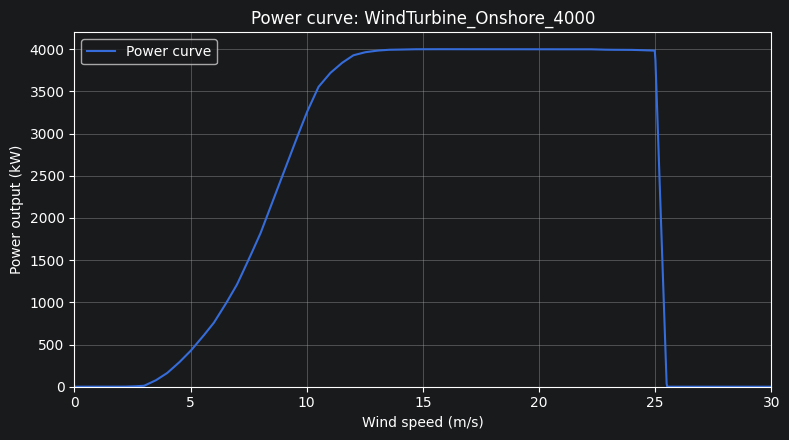

In [7]:
# Vizualize power curve

x_plot = np.linspace(0, 30, 1000)
y_plot = f(x_plot).ravel()

plt.figure(figsize=(8, 4.5))
plt.plot(x_plot, y_plot, label="Power curve")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power output (kW)")
plt.title(f"Power curve: {name}")
plt.legend()
plt.grid(True)
plt.xlim(0, 30)
plt.ylim(0, max(float(rated_capacity) * 1.05, power_output.max() * 1.05))
plt.tight_layout()
plt.show()

In [8]:
# Weather data - DO NOT CHANGE
df = climate_data['dataframe']

if "ws100" in df.columns:
    ws = df["ws100"]
    ws_height = 100
else:
    ws = df["ws10"]
    ws_height = 10

alpha = 1/7

if hubheight > 0:
    ws = ws * (hubheight / ws_height) ** alpha

In [9]:
# defining pv data - DO NOT CHANGE

pv_system_data = dict()
pv_system_data["tilt"] = 18
pv_system_data["surface_azimuth"] = 180
pv_system_data["module_name"] = "SunPower_SPR_X20_327"
pv_system_data["inverter_eff"] = 0.96

inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

In [10]:
# Fitting pv system - DO NOT CHANGE
module_database = pvlib.pvsystem.retrieve_sam("CECMod")
module = module_database[pv_system_data["module_name"]]

temperature_model_parameters = (
    pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS["sapm"][
        "open_rack_glass_glass"
    ]
)

# Create PV model chain
inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

system = pvlib.pvsystem.PVSystem(
    surface_tilt=pv_system_data["tilt"],
    surface_azimuth=pv_system_data["surface_azimuth"],
    module_parameters=module,
    inverter_parameters=inverter_parameters,
    temperature_model_parameters=temperature_model_parameters,
)

# Get location
tz = 'Europe/Amsterdam'

location = pvlib.location.Location(node_lat, node_lon, tz=tz, altitude=node_alt)

pv_model = pvlib.modelchain.ModelChain(
    system, location, spectral_model="no_loss", aoi_model="physical"
)
peakpower = module.STC

In [11]:
# Electricity and L/H Heat, Hydrogen demand data for Point 2
import calendar

skip = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

demand_data_path = 'data/demand_production.xlsx'
df_p2 = pd.read_excel(demand_data_path, sheet_name='Point2', header=1)

el_demand2 = df_p2['Electricity [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
el_demand2 = el_demand2 * electricity_demand_multiplier

L_heat_demand2 = df_p2['Low T Heat [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
L_heat_demand2 = L_heat_demand2 * heat_demand_multiplier

H_heat_demand2 = df_p2['High T Heat [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
H_heat_demand2 = H_heat_demand2 * heat_demand_multiplier

hydrogen_demand2 = df_p2['H2 Demand [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
hydrogen_demand2 = hydrogen_demand2 * hydrogen_demand_multiplier

In [12]:
# Hydrogen availability at production

H2_available = df_p2['H2 Production [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
H2_available = H2_available * hydrogen_production_multiplier

In [13]:
# Energy production

# Hours to skip to reach the selected month
skip_hours = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

# wind capacity factor
capacity_factor_wind = f(np.clip(ws.values, 0, 35)) / 4000
capacity_factor_wind = pd.Series(
    np.asarray(capacity_factor_wind).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)

# solar capacity factor
pv_model.run_model(df)
power = pv_model.results.ac.p_mp
capacity_factor_solar = power / peakpower

capacity_factor_solar = pd.Series(
    np.asarray(capacity_factor_solar).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)

/home/krivero/anaconda3/envs/esi_final/lib/python3.13/site-packages/scipy/optimize/_chandrupatla.py:437: RuntimeWarning: invalid value encountered in divide
  C = A / (A + B)


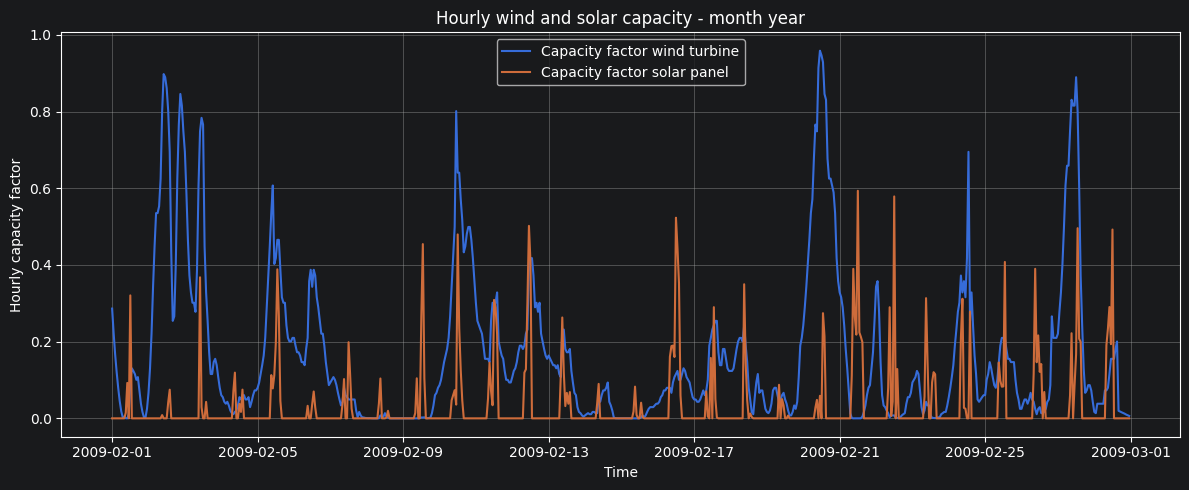

In [14]:
# Plot of capacity factors

plt.figure(figsize=(12, 5))

plt.plot(capacity_factor_wind.index, capacity_factor_wind, label='Capacity factor wind turbine')
plt.plot(capacity_factor_solar.index, capacity_factor_solar, label='Capacity factor solar panel')

plt.xlabel('Time')
plt.ylabel('Hourly capacity factor')
plt.title('Hourly wind and solar capacity - month year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
# Obtaining techno-economic data

tech_eco_data_path = 'data/technoeconomic_data.xlsx'
tech_eco_data = pd.read_excel(tech_eco_data_path, sheet_name='Data', header=2)

def get_value(df, component, data_type):
    mask = (df['component'] == component) & (df['parameter'] == data_type)
    result = df.loc[mask, 'value']
    if len(result) == 0:
        raise ValueError(f"No data found for component='{component}', parameter='{data_type}'")
    return result.values[0]

# We give you the wind turbine techno-economic data import as example. Save all the relevant data with the same function
# !!Make sure to use the correct units!!

# Wind turbine
Wind_capex = get_value(tech_eco_data, 'Wind turbine', 'Investment cost')  # EUR/kW
Wind_lifetime = get_value(tech_eco_data, 'Wind turbine', 'Lifetime')  # year
Wind_opex = get_value(tech_eco_data, 'Wind turbine', 'Opex') / 100  # capex/year

## Start of Model 2 code
### Bring in additional techno-economic data

In [16]:
# grab additional techno-economic data
Solar_capex = get_value(tech_eco_data, 'Solar panel', 'Investment cost')  #EUR/kw
Solar_lifetime = get_value(tech_eco_data, 'Solar panel', 'Lifetime') # year
Solar_opex = get_value(tech_eco_data, 'Solar panel', 'Opex') / 100 # % capex/year math included
Electricity_cable_capex = get_value(tech_eco_data, 'Electricity cable', 'Investment cost') #EUR/kw/km
Electricity_cable_lifetime = get_value(tech_eco_data, 'Electricity cable', 'Lifetime') # year
Electricity_cable_fixed_opex = get_value(tech_eco_data, 'Electricity cable', 'Fixed Opex') / 100 # %capex/year
Electricity_cable_losses = get_value(tech_eco_data, 'Electricity cable', 'Losses') / 100 # % per 100km

# relevant for part 2
Hydrogen_pipeline_capex = get_value(tech_eco_data, 'Hydrogen pipeline', 'Investment cost') # Eur/kw/km
Hydrogen_pipeline_lifetime = get_value(tech_eco_data, 'Hydrogen pipeline', 'Lifetime') # year
Hydrogen_pipeline_fixed_opex = get_value(tech_eco_data, 'Hydrogen pipeline', 'Fixed Opex') /100 # % capex/year
Hydrogen_pipeline_losses = get_value(tech_eco_data, 'Hydrogen pipeline', 'Losses') /100 # % per 100km

Li_ion_battery_capex = get_value(tech_eco_data, 'Li-ion battery', 'Investment cost') # EUR/kWh
Li_ion_battery_lifetime = get_value(tech_eco_data, 'Li-ion battery', 'Lifetime') # year
Li_ion_battery_opex = get_value(tech_eco_data, 'Li-ion battery', 'Opex') / 100 # % capex/year
Li_ion_battery_charging_efficiency = get_value(tech_eco_data, 'Li-ion battery', 'Charging efficiency') / 100 # % input energy
Li_ion_battery_discharging_efficiency = get_value(tech_eco_data, 'Li-ion battery', 'Discharging efficiency') / 100 # % output energy
Li_ion_battery_self_discharge_coefficient = get_value(tech_eco_data, 'Li-ion battery', 'Self-discharge coefficient') / 100 # % per hour
Li_ion_battery_max_charging_capacity = get_value(tech_eco_data, 'Li-ion battery', 'Max charging capacity') / 100 # % size of battery
Li_ion_battery_max_discharging_capacity = get_value(tech_eco_data, 'Li-ion battery', 'Max discharging capacity') / 100 # % size of battery

# relevant for part 2
Hydrogen_storage_tank_capex = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Investment cost') # EUR/kWh
Hydrogen_storage_tank_lifetime = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Lifetime') #year
Hydrogen_storage_tank_opex = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Opex') / 100 # % capex/year
Hydrogen_storage_tank_charging_efficiency = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Charging efficiency') / 100 # % input energy
Hydrogen_storage_tank_discharging_efficiency = get_value(tech_eco_data, 'Hydrogen storage - tank','Discharging efficiency') # error in data this does not need division by 100 % output energy
Hydrogen_storage_tank_self_discharge_coefficient = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Self-discharge coefficient') / 100# %/hour
Hydrogen_storage_tank_max_charging_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max charging capacity') / 100 # %/size
Hydrogen_storage_tank_max_discharging_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max discharging capacity') / 100 # %/size
Hydrogen_storage_tank_max_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max capacity') # NOTE error in data this is actually MWh

Heat_storage_high_temp_capex = get_value(tech_eco_data, 'Heat storage - High temp', 'Investment cost') # EUR/MWh
Heat_storage_high_temp_lifetime = get_value(tech_eco_data, 'Heat storage - High temp', 'Lifetime') # year
Heat_storage_high_temp_opex = get_value(tech_eco_data, 'Heat storage - High temp', 'Opex') / 100 # % capex/year
Heat_storage_high_temp_charging_efficiency = get_value(tech_eco_data, 'Heat storage - High temp', 'Charging efficiency') / 100 # % input energy
Heat_storage_high_temp_discharging_efficiency = get_value(tech_eco_data, 'Heat storage - High temp','Discharging efficiency') / 100 # % output energy
Heat_storage_high_temp_self_discharge_coefficient = get_value(tech_eco_data, 'Heat storage - High temp', 'Self-discharge coefficient')/100 # % / hour
Heat_storage_high_temp_max_charging_capacity = get_value(tech_eco_data, 'Heat storage - High temp', 'Max charging capacity') / 100 # % size
Heat_storage_high_temp_max_discharging_capacity = get_value(tech_eco_data, 'Heat storage - High temp', 'Max discharging capacity') / 100 # % size

Heat_storage_low_temp_capex = get_value(tech_eco_data, 'Heat storage - Low temp', 'Investment cost') # EUR/MWh
Heat_storage_low_temp_lifetime = get_value(tech_eco_data, 'Heat storage - Low temp', 'Lifetime') # year
Heat_storage_low_temp_opex = get_value(tech_eco_data, 'Heat storage - Low temp', 'Opex') /100 # % capex/year
Heat_storage_low_temp_charging_efficiency = get_value(tech_eco_data, 'Heat storage - Low temp', 'Charging efficiency') / 100 # % input energy
Heat_storage_low_temp_discharging_efficiency = get_value(tech_eco_data, 'Heat storage - Low temp','Discharging efficiency') / 100# % output energy
Heat_storage_low_temp_self_discharge_coefficient = get_value(tech_eco_data, 'Heat storage - Low temp', 'Self-discharge coefficient') / 100 # % / hour
Heat_storage_low_temp_max_charging_capacity = get_value(tech_eco_data, 'Heat storage - Low temp', 'Max charging capacity') / 100 # % size
Heat_storage_low_temp_max_discharging_capacity = get_value(tech_eco_data, 'Heat storage - Low temp', 'Max discharging capacity') / 100 # % size

Heat_pump_coefficient_of_performance = get_value(tech_eco_data, 'Heat pump', 'COP') # no unit
Hydrogen_boiler_efficiency = get_value(tech_eco_data, 'Hydrogen boiler', 'Efficiency') / 100 # % input energy

Operational_cost_lost_load_penalty = get_value(tech_eco_data, 'Operational cost', 'Lost load penalty') # EUR/MWh
Operational_cost_max_import_availability = get_value(tech_eco_data, 'Operational cost', 'Max import availability') # MWh
Operational_cost_electricity_import_cost = get_value(tech_eco_data, 'Operational cost', 'Electricity import cost') # EUR/MWh
Operational_cost_hydrogen_market_price = get_value(tech_eco_data, 'Operational cost', 'Hydrogen market price') # EUR/MWh

## PyPSA Model for Part 2 - Full Optimization
The code below is shared as an exemple of the PyPSA model structure used for analysis of the Part 2 design. Different scenarios were made with different choices in the model parameters to encourage different results in the KPIs of system cost, RES curtailment, utilization factor of the line, and unserved demand. Continue to the ***Comparison Section*** for comparison across scenarios.

In [17]:
# PyPSA Part 2 Model roughly following 3-node expansion example
# https://docs.pypsa.org/latest/examples/3-node-cem/

In [18]:
import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pypsa
from pypsa.costs import annuity



In [19]:
# data prep and variables

# p_nom_min_solar = 50
marginal_cost_wind = 0 # gave 0 here. assumed included in opex
marginal_cost_solar = 0

# Battery parameters
p_nom_bat_guess = 10  # MW, initial guess
max_p_nom_batt = 500
# battery_energy_capacity = 25  # MWh, from your Li-ion spec
# battery_max_hours = battery_energy_capacity / p_nom_guess
eta_charge = Li_ion_battery_charging_efficiency # eta is efficiency
eta_discharge = Li_ion_battery_discharging_efficiency
max_charge_pu = Li_ion_battery_max_charging_capacity

#transmission
efficiency_transmission_12 = (1 - Electricity_cable_losses) ** (distance12 / 100)  # = 0.9737 for 53km
efficiency_transmission_23 = (1 - Hydrogen_pipeline_losses) ** (distance23 / 100)

# H2
p_nom_h2 = H2_available.max()
H2_available = H2_available.copy()
H2_available.index = pd.to_datetime(times)
H2_available.index = H2_available.index.tz_localize(None)
p_max_pu_h2 = H2_available / p_nom_h2

# annualize the CAPEX
r = 0.05
simulation_hours = len(times)
monthly_annualizer= simulation_hours/8760

annualized_capex_wind = (Wind_capex*1000) * annuity(r, Wind_lifetime)
annualized_capex_solar = (Solar_capex*1000) * annuity(r, Solar_lifetime)
# annualized_capex_wind_manual = 80600 # eur/MW/y
# annualized_capex_solar_manual = 34200 # eur/MW/y
max_hours_bat = 4 #
annualized_capex_battery = (Li_ion_battery_capex*1000) * max_hours_bat * annuity(r, Li_ion_battery_lifetime) #eur/Mwh * h * annuity = eur/MW

annualized_capex_hydrogen_storage = (Hydrogen_storage_tank_capex*1000) * annuity(r, Hydrogen_storage_tank_lifetime) #eur/MWh # unlike battery PyPSA wants this in MWh, for energy capacity
annualized_capex_heat_high_storage = (Heat_storage_high_temp_capex) * annuity(r, Heat_storage_high_temp_lifetime) # capex already in MWh
annualized_capex_heat_low_storage = (Heat_storage_low_temp_capex) * annuity(r, Heat_storage_low_temp_lifetime)
# capital_cost_power ≈ (1 / C_rate) × capital_cost_energy
heat_high_charge_capex = (1/Heat_storage_high_temp_max_charging_capacity)*Heat_storage_high_temp_capex
heat_low_charge_capex = (1/Heat_storage_low_temp_max_charging_capacity)*Heat_storage_low_temp_capex
#discharge is same %

annualized_capex_transmission = (Electricity_cable_capex*1000) * distance12 * annuity(r, Electricity_cable_lifetime) # Eur/kw/km * 1000 * km
annualized_capex_pipeline = (Hydrogen_pipeline_capex*1000) * distance23 * annuity(r, Hydrogen_pipeline_lifetime) # eur/kW/km * 1000 * km

#annualize the OPEX
annualized_opex_wind = (Wind_capex * 1000) * Wind_opex  # overnight capex * % = €/MW/year
annualized_opex_solar = (Solar_capex * 1000) * Solar_opex
annualized_opex_battery = (Li_ion_battery_capex * 1000) * Li_ion_battery_opex

annualized_opex_hydrogen_storage = (Hydrogen_storage_tank_capex*1000) * Hydrogen_storage_tank_opex
annualized_opex_heat_high_storage = (Heat_storage_high_temp_capex) * Heat_storage_high_temp_opex # in MWh already so no convert
annualized_opex_heat_low_storage = (Heat_storage_low_temp_capex) * Heat_storage_low_temp_opex

annualized_opex_transmission = (Electricity_cable_capex* 1000) * distance12 * Electricity_cable_fixed_opex # fixme is fixed different?
annualized_opex_pipeline = (Hydrogen_pipeline_capex* 1000) * distance23 * Hydrogen_pipeline_fixed_opex

capital_cost_solar = (annualized_capex_solar + annualized_opex_solar)*monthly_annualizer
capital_cost_wind = (annualized_capex_wind + annualized_opex_wind)*monthly_annualizer
capital_cost_battery = (annualized_capex_battery + annualized_opex_battery)*monthly_annualizer #confusion around whether multiplying by max hours is needed but I think correct
capital_cost_hydrogen_storage = (annualized_capex_hydrogen_storage + annualized_opex_hydrogen_storage)*monthly_annualizer
capital_cost_heat_high_storage = (annualized_capex_heat_high_storage + annualized_opex_heat_high_storage) * monthly_annualizer
capital_cost_heat_low_storage = (annualized_capex_heat_low_storage + annualized_opex_heat_low_storage) * monthly_annualizer
capital_cost_transmission = (annualized_capex_transmission + annualized_opex_transmission)*monthly_annualizer
capital_cost_pipeline = (annualized_capex_pipeline + annualized_opex_pipeline) * monthly_annualizer

# conversions timestamp based index vs. integer, repulling from df_p2 so need to re-multiply
el_demand2 = df_p2['Electricity [MWh]'].iloc[skip : skip + len(times)]
el_demand2 = el_demand2.set_axis(times)
el_demand2 = el_demand2 * electricity_demand_multiplier
el_demand2.index = pd.to_datetime(el_demand2.index).tz_localize(None)

L_heat_demand2 = df_p2['Low T Heat [MWh]'].iloc[skip : skip + len(times)]
L_heat_demand2 = L_heat_demand2.set_axis(times)
L_heat_demand2 = L_heat_demand2 * heat_demand_multiplier
L_heat_demand2.index = pd.to_datetime(L_heat_demand2.index).tz_localize(None)

H_heat_demand2 = df_p2['High T Heat [MWh]'].iloc[skip : skip + len(times)]
H_heat_demand2 = H_heat_demand2.set_axis(times)
H_heat_demand2 = H_heat_demand2 * heat_demand_multiplier
H_heat_demand2.index = pd.to_datetime(H_heat_demand2.index).tz_localize(None)

hydrogen_demand2 = df_p2['H2 Demand [MWh]'].iloc[skip : skip + len(times)]
hydrogen_demand2 = hydrogen_demand2.set_axis(times)
hydrogen_demand2 = hydrogen_demand2 * hydrogen_demand_multiplier
hydrogen_demand2.index = pd.to_datetime(hydrogen_demand2.index).tz_localize(None)

H2_available = df_p2['H2 Production [MWh]'].iloc[skip : skip + len(times)]
H2_available = H2_available.set_axis(times)
H2_available = H2_available * hydrogen_production_multiplier
H2_available.index = pd.to_datetime(H2_available.index).tz_localize(None)

capacity_factor_wind.index = pd.to_datetime(capacity_factor_wind.index).tz_localize(None)
capacity_factor_solar.index = pd.to_datetime(capacity_factor_solar.index).tz_localize(None)

ts = pd.concat(
    [
        el_demand2.rename("e_load_mw"),
        L_heat_demand2.rename("l_heat_load"),
        H_heat_demand2.rename("h_heat_load"),
        hydrogen_demand2.rename("hydrogen_demand"),
        H2_available.rename("H2_available"),
        capacity_factor_wind.rename("wind_pu"),
        capacity_factor_solar.rename("solar_pu"),
    ],
    axis=1
)

# sanity check
assert len(ts) == len(times), f"Time series length mismatch: {len(ts)} vs {len(times)}"

#network setup
RESOLUTION = 1 # hourly
n = pypsa.Network()
ts.index = ts.index.tz_localize(None)
n.set_snapshots(ts.index)
n.snapshot_weightings.loc[:, :] = RESOLUTION

REGIONS = ["zone1", "zone2", "zone3"]

REGION_COORDS = {
    "zone1": {"lat": node_lat, "lon": node_lon},
    "zone2": {"lat": 54.279,  "lon": 10.164},
    "zone3": {"lat": 54.279,  "lon": 11.691},
}

REGION_CARRIERS = {
    "zone1": ["electricity"],
    "zone2": ["electricity", "heat_low_temp", "heat_high_temp", "hydrogen"],
    "zone3": ["hydrogen"],
}

#creating buses per region and carrier e.g. zone1_electricity
for region in REGIONS:
    for carrier in REGION_CARRIERS[region]:
        bus_name = f"{region}_{carrier}"

        n.add(
            "Bus",
            bus_name,
            carrier=carrier,
            x=REGION_COORDS[region]["lon"],
            y=REGION_COORDS[region]["lat"],
        )

def bus(region, carrier):
    assert region in REGIONS
    assert carrier in REGION_CARRIERS[region]
    return f"{region}_{carrier}"

carriers = [
    # Energy carriers (core system)
    "electricity",
    "heat_low_temp",
    "heat_high_temp",
    "hydrogen",

    # Generation
    "wind",
    "solar",

    # Storage
    "battery",
    "hydrogen storage",
    "heat_low_storage",
    "heat_high_storage",

    # Conversion / system
    # "electrolysis",
    "heat pump",
    "h2 boiler",

    # Other
    "hydrogen pipeline",
    "load shedding",
    "imported electricity",
]
colors = [
    # Energy carriers (core system)
    "white",           # electricity
    "lightsalmon",     # heat_low_temp
    "orangered",       # heat_high_temp
    "purple",          # hydrogen

    # Generation
    "dodgerblue",      # wind
    "gold",            # solar

    # Storage
    "darkorange",      # battery
    "mediumpurple",    # hydrogen storage
    "lightcoral",      # heat_low_storage
    "tomato",          # heat_high_storage

    # Conversion / system
    "green",           # heat pump
    "orchid",          # h2 boiler

    # Other
    "lightblue",       # hydrogen pipeline
    "red",             # load shedding
    "lightgreen",      # imported electricity
]
n.add("Carrier", carriers, color=colors)

# COMPONENTS SECTION
# GENERATION
n.add(
    "Generator",
    "solar_zone1",
    bus=bus("zone1", "electricity"),
    carrier="solar",
    p_max_pu=ts.solar_pu,
    capital_cost=capital_cost_solar, # using MW
    marginal_cost=marginal_cost_solar,
    p_nom_extendable=True, #note allows PyPSA optimization to choose how much capacity to build
)

n.add("Generator",
    "wind_zone1",
    bus=bus("zone1", "electricity"),
    carrier="wind",
    p_max_pu=ts.wind_pu,
    capital_cost=capital_cost_wind, # using MW
    marginal_cost=marginal_cost_wind,
    p_nom_extendable=True, #note allows PyPSA optimization to choose how much capacity to build
)

n.add(
    "Generator",
    "load shedding",
    bus=bus("zone2", "electricity"),
    carrier="load shedding",
    marginal_cost=Operational_cost_lost_load_penalty,
    p_nom=ts.e_load_mw.max(),
    # p_max_pu=0.05,  # at any hour, max shedding = 5% of p_nom
)

n.add(
    "Generator",
    "import",
    bus=bus("zone2", "electricity"),
    carrier="imported electricity",
    marginal_cost=Operational_cost_electricity_import_cost,        # existing variable, €/MWh
    p_nom=Operational_cost_max_import_availability,    # existing variable, MW
    p_nom_extendable=False, # can't expand capacity any more than max
)

n.add(
    "Generator",
    "h2_zone3",
    bus=bus("zone3", "hydrogen"),
    carrier="hydrogen",
    p_nom=p_nom_h2,
    p_max_pu=p_max_pu_h2,
    marginal_cost=Operational_cost_hydrogen_market_price, # eur/MWh
)

n.add("Generator", "loadshed_hydrogen",
    bus=bus("zone2", "hydrogen"),
    carrier="load shedding",
    marginal_cost=Operational_cost_lost_load_penalty,
    p_nom=ts.hydrogen_demand.max())

n.add("Generator", "loadshed_heat_high",
    bus=bus("zone2", "heat_high_temp"),
    carrier="load shedding",
    marginal_cost=Operational_cost_lost_load_penalty,
    p_nom=ts.h_heat_load.max()
)

n.add("Generator", "loadshed_heat_low",
    bus=bus("zone2", "heat_low_temp"),
    carrier="load shedding",
    marginal_cost=Operational_cost_lost_load_penalty,
    p_nom=ts.l_heat_load.max()
)

# DEMAND
# Electricity demand
n.add(
    "Load",
    "electricity_demand",
    bus=bus("zone2", "electricity"),
    carrier="electricity",
    p_set=ts.e_load_mw,
)

# Low-temperature heat demand
n.add(
    "Load",
    "heat_low_demand",
    bus=bus("zone2", "heat_low_temp"),
    carrier="heat_low_temp",
    p_set=ts.l_heat_load,   # make sure this is your low-temp heat time series
)

# High-temperature heat demand
n.add(
    "Load",
    "heat_high_demand",
    bus=bus("zone2", "heat_high_temp"),
    carrier="heat_high_temp",
    p_set=ts.h_heat_load,  # make sure this is your high-temp heat time series
)

# Hydrogen demand
n.add(
    "Load",
    "hydrogen_demand",
    bus=bus("zone2", "hydrogen"),
    carrier="hydrogen",
    p_set=ts.hydrogen_demand,  # hydrogen demand in MW
)

# STORAGE
n.add(
    "StorageUnit",
    "battery storage zone 1", # manually swap batteries
    bus=bus("zone1", "electricity"),
    carrier="battery",
    p_nom=p_nom_bat_guess, #MW
    p_nom_extendable=True,
    p_nom_max=max_p_nom_batt,
    max_hours=max_hours_bat, # E_max = p_nom * max_hours battery can go 4 hours at full discharge
    capital_cost=capital_cost_battery,
    efficiency_store=eta_charge,
    efficiency_dispatch=eta_discharge,
    standing_loss=Li_ion_battery_self_discharge_coefficient,
    p_max_pu=max_charge_pu,    # max discharge capacity = 50% of p_nom
    p_min_pu=-max_charge_pu,   # max charge capacity = 50% of p_nom (note: negative = charging)
    state_of_charge_initial=0.5 * p_nom_bat_guess * max_hours_bat,
)

# n.add(
#     "StorageUnit",
#     "battery storage zone 2", #manually swap in
#     bus="zone2",
#     carrier="battery storage",
#     p_nom=p_nom_guess, #MW
#     # max_hours=e_nom/p_nom, # E_max = p_nom * max_hours battery can go 3 hours at full discharge
#     capital_cost=capital_cost_battery,
#     efficiency_store=eta_charge,
#     efficiency_dispatch=eta_discharge,
#     standing_loss=0.00004,
#     p_max_pu=max_charge_pu,    # max discharge capacity = 50% of p_nom
#     p_min_pu=-max_charge_pu,   # max charge capacity = 50% of p_nom (note: negative = charging)
#     e_nom_extendable=True, # allowing capacity to increase in MWh
#     cyclic_state_of_charge=True, #The battery’s state of charge at the end of the simulation equals its starting state. Ensures no net energy accumulation over the optimization horizon. Important for representing a full year or cyclic operation
# )

#h2 storage section - note requires accompanying links to account for charge/discharge parameters
n.add(
    "Bus",
    "h2_storage_internal",
    carrier="hydrogen",
)

n.add(
    "Store",
    "h2_storage_zone3",
    bus="h2_storage_internal",
    carrier="hydrogen storage",
    e_nom_extendable=True,
    e_nom_max = Hydrogen_storage_tank_max_capacity,
    capital_cost=capital_cost_hydrogen_storage,
    e_cyclic=True,           # optional: end level = start level
    standing_loss=Hydrogen_storage_tank_self_discharge_coefficient
)

n.add(
    "Link",
    "h2_charge_zone3",
    bus0=bus("zone3", "hydrogen"),
    bus1="h2_storage_internal",
    efficiency=Hydrogen_storage_tank_charging_efficiency,
    p_nom=Hydrogen_storage_tank_max_charging_capacity * Hydrogen_storage_tank_max_capacity,   # MW = % * MWh assuming % was hourly c-rate
    carrier="hydrogen storage",
)

n.add(
    "Link",
    "h2_discharge_zone3",
    bus0="h2_storage_internal",
    bus1=bus("zone3", "hydrogen"),
    efficiency=Hydrogen_storage_tank_discharging_efficiency,
    p_nom=Hydrogen_storage_tank_max_discharging_capacity * Hydrogen_storage_tank_max_capacity,  # MW = % * MWh assuming % was hourly crate
    carrier="hydrogen storage",
)

# heat storage section
n.add(
    "Bus",
    "heat_low_storage_internal",
    carrier="heat_low_temp",
)

n.add(
    "Bus",
    "heat_high_storage_internal",
    carrier="heat_high_temp",
)

n.add(
    "Store",
    "heat_low_storage",
    bus="heat_low_storage_internal",
    carrier="heat_low_storage",
    e_nom=0,
    e_nom_extendable=True,
    standing_loss=Heat_storage_low_temp_self_discharge_coefficient,
    capital_cost=capital_cost_heat_low_storage,
    e_cyclic=True,
)

n.add(
    "Store",
    "heat_high_storage",
    bus="heat_high_storage_internal",
    carrier="heat_high_storage",
    e_nom=0,
    e_nom_extendable=True,
    standing_loss=Heat_storage_high_temp_self_discharge_coefficient,
    capital_cost=capital_cost_heat_high_storage,
    e_cyclic=True,
)

n.add(
    "Link",
    "heat_low_charge",
    bus0=bus("zone2", "heat_low_temp"),
    bus1="heat_low_storage_internal",
    efficiency=Heat_storage_low_temp_charging_efficiency,
    p_nom_extendable=True,
    capital_cost=heat_low_charge_capex, #workaround for max charging capacity inclusion
    carrier="heat_low_storage",
)

n.add(
    "Link",
    "heat_low_discharge",
    bus0="heat_low_storage_internal",
    bus1=bus("zone2", "heat_low_temp"),
    efficiency=Heat_storage_low_temp_discharging_efficiency,
    p_nom_extendable=True,
    capital_cost=heat_low_charge_capex, #same rate for discharge
    carrier="heat_low_storage",
)

n.add(
    "Link",
    "heat_high_charge",
    bus0=bus("zone2", "heat_high_temp"),
    bus1="heat_high_storage_internal",
    efficiency=Heat_storage_high_temp_charging_efficiency,
    p_nom_extendable=True,
    capital_cost=heat_high_charge_capex,
    carrier="heat_high_storage",
)

n.add(
    "Link",
    "heat_high_discharge",
    bus0="heat_high_storage_internal",
    bus1=bus("zone2", "heat_high_temp"),

    efficiency=Heat_storage_high_temp_discharging_efficiency,
    p_nom_extendable=True,
    capital_cost=heat_high_charge_capex,
    carrier="heat_high_storage",
)

#TRANSMISSION
# Electricity line from zone1 to zone2
n.add(
    "Link",
    "zone1-zone2",
    bus0=bus("zone1", "electricity"),
    bus1=bus("zone2", "electricity"),
    efficiency=efficiency_transmission_12,
    # p_nom = p_nom_guess # MW max capacity if fixed
    p_nom_extendable=True,        # allows optimization
    capital_cost=capital_cost_transmission,  # €/MW
    carrier="electricity",
)

#h2 pipeline
# Hydrogen pipeline from zone3 to zone2
n.add(
    "Link",
    "zone3-zone2",
    bus0=bus("zone3", "hydrogen"),
    bus1=bus("zone2", "hydrogen"),
    efficiency=efficiency_transmission_23,
    p_nom_extendable=True,  # optimize pipeline capacity
    capital_cost=capital_cost_pipeline,  # €/MW
    carrier="hydrogen pipeline",
)

#CONVERSION
n.add(
    "Link",
    "heatpump_zone2",
    bus0=bus("zone2", "electricity"),
    bus1=bus("zone2", "heat_low_temp"),
    efficiency=Heat_pump_coefficient_of_performance,
    p_nom_extendable=True,      # lets PyPSA choose size
    # capital_cost=capital_cost_heatpump,  # €/MW_electricity input assume preexisting infra no cost
    carrier="heat pump",
)

n.add(
    "Link",
    "h2_boiler_zone2",
    bus0=bus("zone2", "hydrogen"),
    bus1=bus("zone2", "heat_high_temp"),
    efficiency=Hydrogen_boiler_efficiency,   # fraction of H2 energy converted to heat
    p_nom_extendable=True,              # size is optimized
    # capital_cost=capital_cost_h2_boiler, # assumed this is preexisting infra so no cost
    carrier="h2 boiler",
)

for bus_name in n.buses.index:
    loads = n.loads[n.loads.bus == bus_name].index.tolist()
    gens = n.generators[n.generators.bus == bus_name].index.tolist()
    links_in = n.links[n.links.bus1 == bus_name].index.tolist()
    if loads and not gens and not links_in:
        print(f"ISOLATED: {bus_name} has demand but no supply path")

n.optimize()

/tmp/ipykernel_141056/3990596941.py:534: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 255.85it/s]
INFO:linopy.io: Writing time: 0.28s


Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-uric5hgi has 41008 rows; 18159 cols; 73376 nonzeros
Coefficient ranges:
  Matrix  [1e-04, 4e+00]
  Cost    [1e+00, 3e+05]
  Bound   [1e+05, 1e+05]
  RHS     [8e-01, 5e+02]
Presolving model
17585 rows, 17597 cols, 48050 nonzeros  0s
Dependent equations search running on 6672 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
15521 rows, 15533 cols, 43987 nonzeros  0s
Presolve reductions: rows 15521(-25487); columns 15533(-2626); nonzeros 43987(-29389) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.0441856169e+05 Pr: 2690(41531.3) 0.1s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 18159 primals, 41008 duals
Objective: 1.06e+07
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


      12890     1.0602523543e+07 Pr: 0(0); Du: 0(1.40745e-13) 1.5s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-uric5hgi
Model status        : Optimal
Simplex   iterations: 12890
Objective value     :  1.0602523543e+07
P-D objective error :  8.7839704097e-17
HiGHS run time      :          1.54


('ok', 'optimal')

In [20]:
#demand landscape
# print(ts.e_load_mw.describe())
# print(ts.l_heat_load.sum())
# print(ts.h_heat_load.sum())
# print(ts.hydrogen_demand.sum())


In [32]:
n.statistics(bus_carrier=None)

Optimal Capacity  Installed Capacity  \
Generator   hydrogen                      39.84930             39.8493   
            imported electricity          25.00000             25.0000   
            load shedding                 93.11060             93.1106   
            solar                         37.52754              0.0000   
            wind                         109.26628              0.0000   
Link        electricity                   37.11023              0.0000   
            h2 boiler                     24.43252              0.0000   
            heat pump                     10.61802              0.0000   
            hydrogen pipeline             33.49699              0.0000   
            hydrogen storage             100.00000            100.0000   
Load        electricity                    0.00000              0.0000   
            heat_high_temp                 0.00000              0.0000   
            heat_low_temp                  0.00000              0.0000   
            hydrogen                       0.00000              0.0000   
StorageUnit battery                       34.42872             10.0000   
Store       hydrogen storage             100.00000              0.0000   

                                       Supply   Withdrawal  Energy Balance  \
Generator   hydrogen              15313.34087      0.00000     15313.34087   
            imported electricity   8569.22203      0.00000      8569.22203   
            load shedding          2708.58257      0.00000      2708.58257   
            solar                   678.50045      0.00000       678.50045   
            wind                   9856.04364      0.00000      9856.04364   
Link        electricity               0.00000  10498.50501    -10498.50501   
            h2 boiler                 0.00000   9531.52256     -9531.52256   
            heat pump                 0.00000   5927.33497     -5927.33497   
            hydrogen pipeline         0.00000  15229.44557    -15229.44557   
            hydrogen storage          0.00000   1286.46322     -1286.46322   
Load        electricity               0.00000  12871.89984    -12871.89984   
            heat_high_temp            0.00000   8891.00246     -8891.00246   
            heat_low_temp             0.00000  20745.67241    -20745.67241   
            hydrogen                  0.00000   5562.30612     -5562.30612   
StorageUnit battery                1061.14611   1097.18519       -36.03908   
Store       hydrogen storage        601.28396    602.95775        -1.67379   

                                  Transmission  Capacity Factor  Curtailment  \
Generator   hydrogen                   0.00000         0.571847   1905.27792   
            imported electricity       0.00000         0.510073   8230.77797   
            load shedding              0.00000         0.043289  59861.73912   
            solar                      0.00000         0.026905    178.65166   
            wind                       0.00000         0.134229   2552.45100   
Link        electricity            10498.50501         0.420983      0.00000   
            h2 boiler                  0.00000         0.580530      0.00000   
            heat pump                  0.00000         0.830705      0.00000   
            hydrogen pipeline      15229.44557         0.676564      0.00000   
            hydrogen storage        1286.46322         0.019144      0.00000   
Load        electricity                0.00000              NaN      0.00000   
            heat_high_temp             0.00000              NaN      0.00000   
            heat_low_temp              0.00000              NaN      0.00000   
            hydrogen                   0.00000              NaN      0.00000   
StorageUnit battery                    0.00000         0.093288  11604.08999   
Store       hydrogen storage           0.00000         0.311345      0.00000   

                                  Capital Expenditure  \
Generator   hydrogen          

In [21]:
# optimized capacities in MW
print()
n.statistics.optimal_capacity()

component    carrier             
Generator    hydrogen                 39.84930
             imported electricity     25.00000
             load shedding            93.11060
             solar                    37.52754
             wind                    109.26628
Link         electricity              37.11023
             h2 boiler                24.43252
             heat pump                10.61802
             hydrogen pipeline        33.49699
             hydrogen storage        100.00000
StorageUnit  battery                  34.42872
Store        hydrogen storage        100.00000
dtype: float64

System Cost - Part 2 - Full Optimization

Total system cost: €2725136.39/month


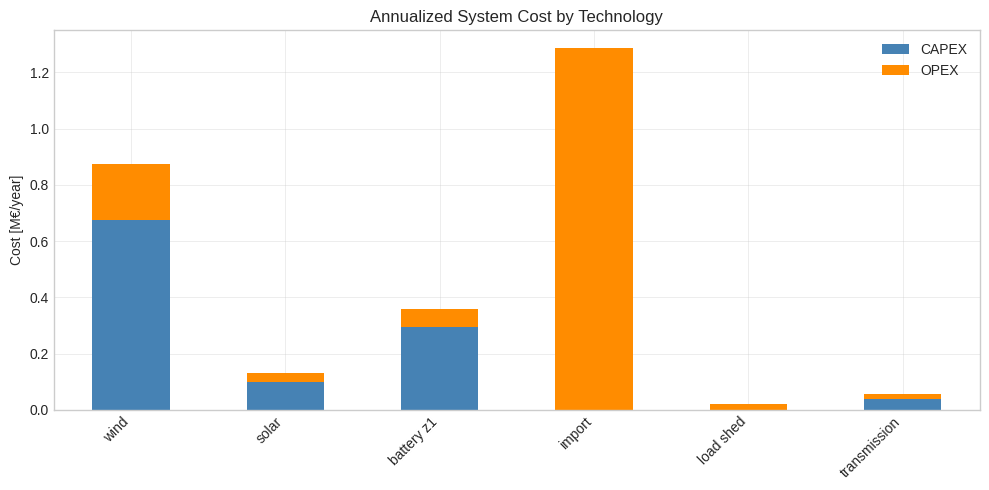

In [22]:
# ── Optimized capacities ─────────────────────────────
opt_wind_mw = n.generators.p_nom_opt.get("wind_zone1", 0)
opt_solar_mw = n.generators.p_nom_opt.get("solar_zone1", 0)
opt_battery_z1_mw = n.storage_units.p_nom_opt.get("battery storage zone 1", 0)
# opt_battery_z2_mw = n.storage_units.p_nom_opt.get("battery storage zone 2", 0)

opt_transmission_mw = n.links.p_nom_opt.get("zone1-zone2", 0)

# ── Energy usage ─────────────────────────────────────
opt_import_mwh = n.generators_t.p.get("import", pd.Series(dtype=float)).sum()
opt_loadshed_mwh = n.generators_t.p.get("load shedding", pd.Series(dtype=float)).sum()

# ── Cost reconstruction ─────────────────────────────
cost_data = {
    "wind": {
        "CAPEX": annualized_capex_wind * opt_wind_mw * monthly_annualizer,
        "OPEX":  annualized_opex_wind  * opt_wind_mw * monthly_annualizer,
    },
    "solar": {
        "CAPEX": annualized_capex_solar * opt_solar_mw * monthly_annualizer,
        "OPEX":  annualized_opex_solar  * opt_solar_mw * monthly_annualizer,
    },
    "battery z1": {
        "CAPEX": annualized_capex_battery * opt_battery_z1_mw * monthly_annualizer,
        "OPEX":  annualized_opex_battery  * opt_battery_z1_mw * monthly_annualizer,
    },
    "import": {
        "CAPEX": 0,
        "OPEX":  Operational_cost_electricity_import_cost * opt_import_mwh,
    },
    "load shed": {
        "CAPEX": 0,
        "OPEX":  Operational_cost_lost_load_penalty * opt_loadshed_mwh,
    },
    "transmission": {
        "CAPEX": annualized_capex_transmission * opt_transmission_mw* monthly_annualizer,
        "OPEX":  annualized_opex_transmission  * opt_transmission_mw* monthly_annualizer,
    },
}

cost_df = pd.DataFrame(cost_data).T.div(1e6)  # M€

# ── Outputs ─────────────────────────────────────────
total_monthly_cost = (cost_df['CAPEX'].sum() + cost_df['OPEX'].sum()) *1e6
print(f"Total system cost: €{total_monthly_cost:.2f}/month")

# ── Plot ────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))
cost_df[["CAPEX", "OPEX"]].plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["steelblue", "darkorange"],
)

ax.set_ylabel("Cost [M€/year]")
ax.set_title("Annualized System Cost by Technology")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Energy Balance

(<Figure size 1666.5x500 with 1 Axes>,
 <Axes: xlabel='snapshot', ylabel='Energy Balance []'>,
 <seaborn.axisgrid.FacetGrid at 0x7e333efac830>)

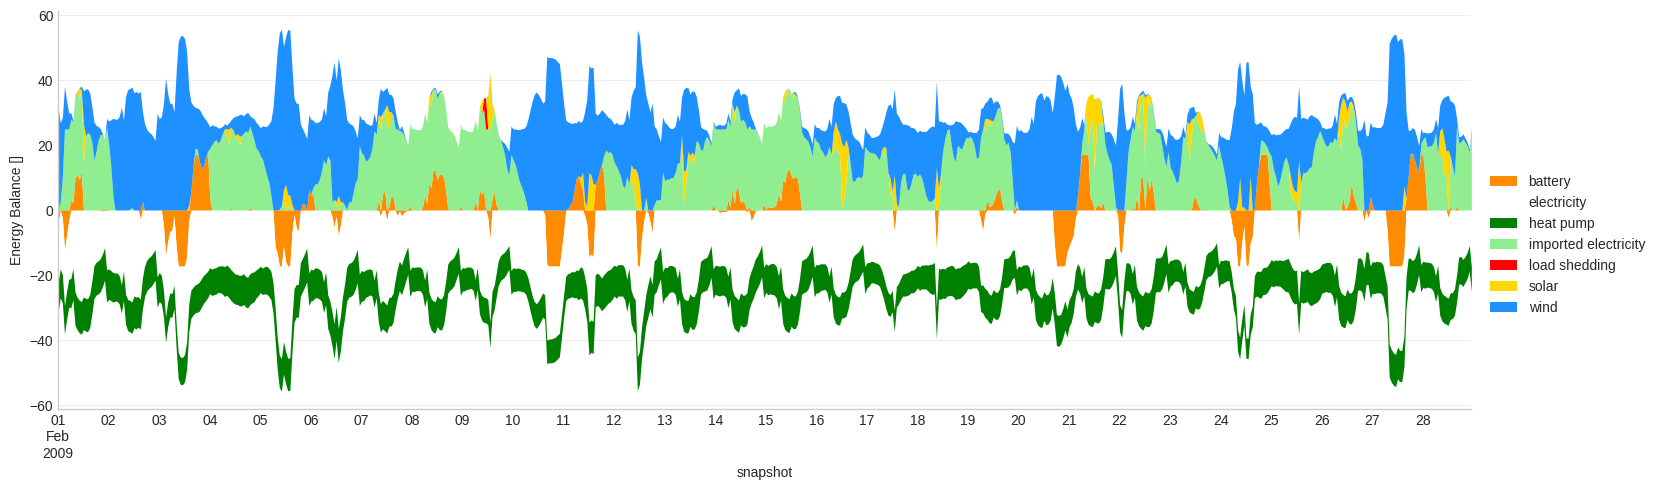

In [23]:
# Energy balances plot as time series (in MW):
sum(ts.e_load_mw)
n.statistics.energy_balance.plot.area(linewidth=0, bus_carrier="electricity",figsize=(15,5))

<Axes: xlabel='snapshot'>

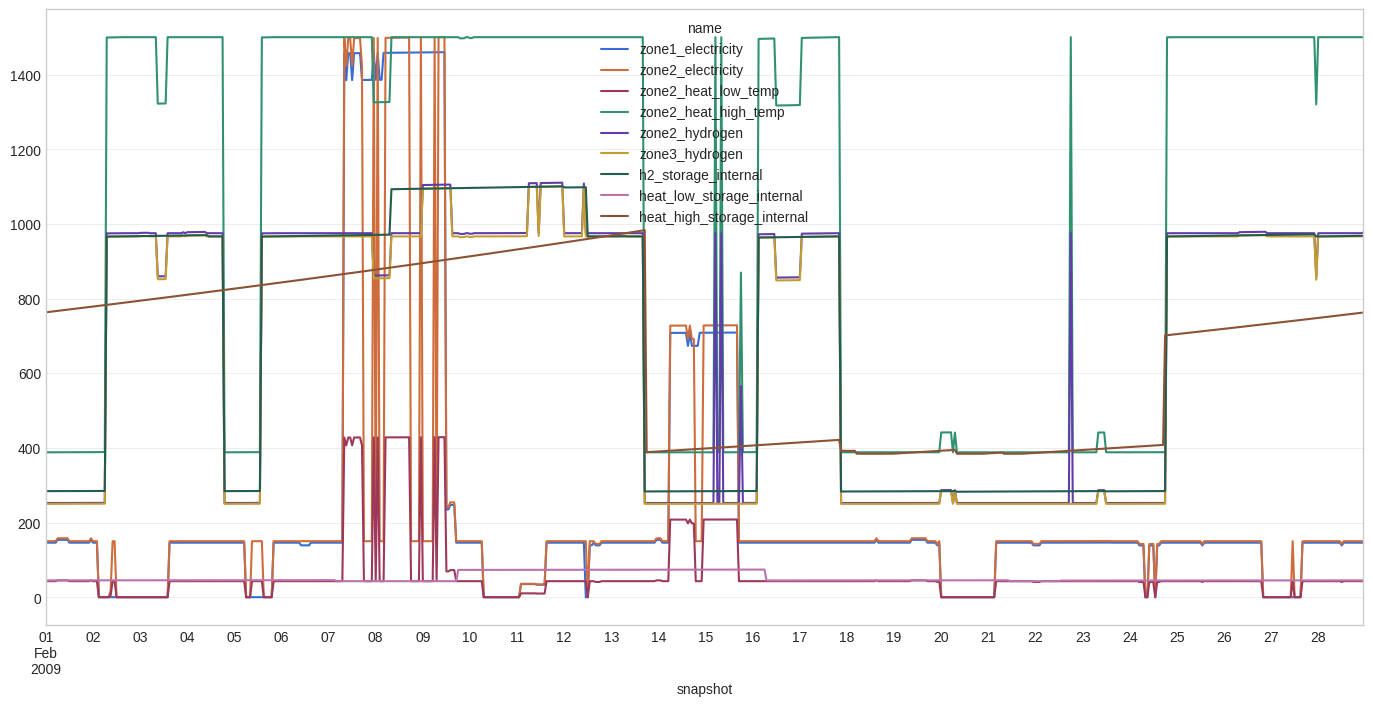

In [24]:
# Price time series for electricity:
n.buses_t.marginal_price.plot(figsize=(17, 8))

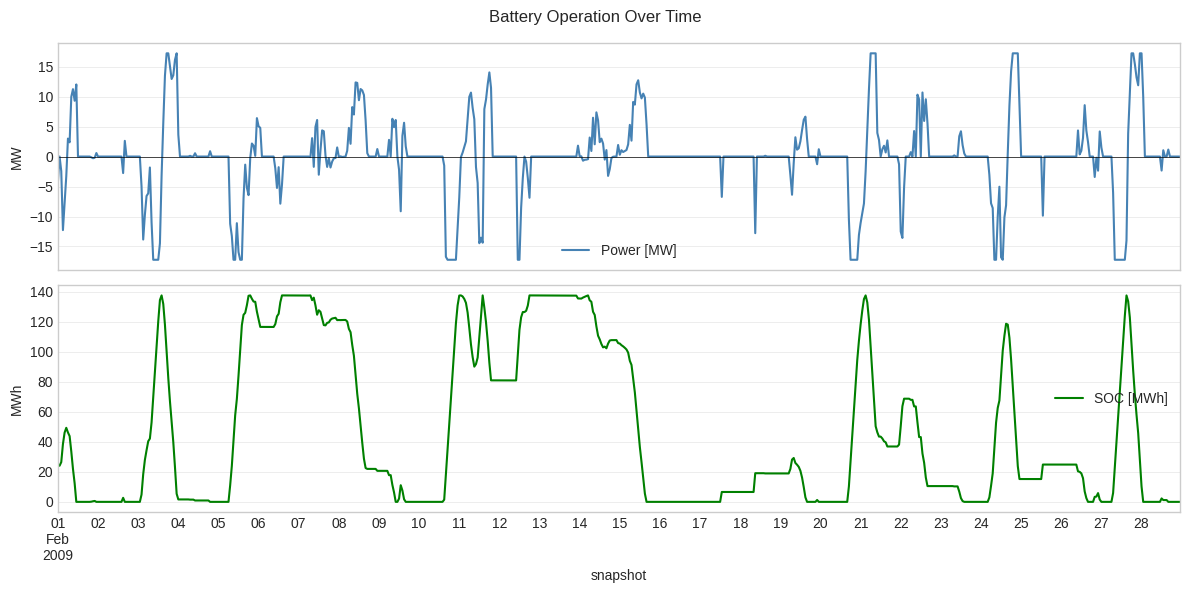

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Charge / discharge power
# n.storage_units_t.p["battery storage zone 2"].plot(
n.storage_units_t.p["battery storage zone 1"].plot(
    ax=axes[0], label="Power [MW]", color="steelblue"
)
axes[0].set_ylabel("MW")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].legend()
axes[0].grid(True)

# Zone 2 SOC
# n.storage_units_t.state_of_charge["battery storage zone 2"].plot(
n.storage_units_t.state_of_charge["battery storage zone 1"].plot(
    ax=axes[1], label="SOC [MWh]", color="green"
)
axes[1].set_ylabel("MWh")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Battery Operation Over Time")
plt.tight_layout()
plt.show()

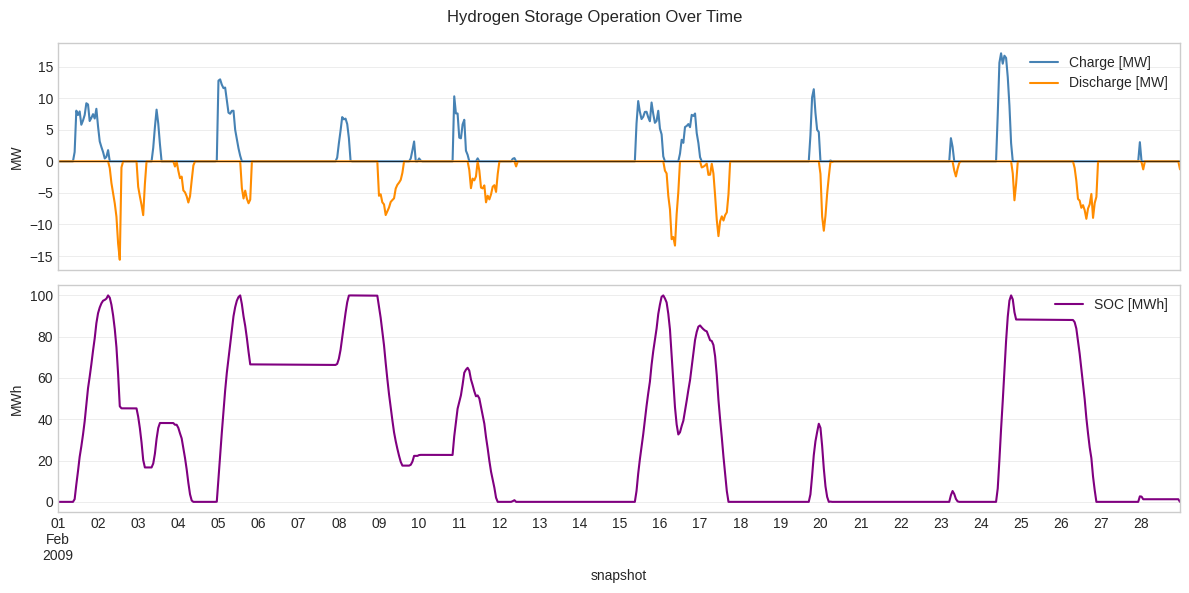

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Charge / discharge power (links)
n.links_t.p0["h2_charge_zone3"].plot(
    ax=axes[0], label="Charge [MW]", color="steelblue"
)
(-n.links_t.p0["h2_discharge_zone3"]).plot(
    ax=axes[0], label="Discharge [MW]", color="darkorange"
)

axes[0].set_ylabel("MW")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].legend()
axes[0].grid(True)

# State of charge (Store)
n.stores_t.e["h2_storage_zone3"].plot(
    ax=axes[1], label="SOC [MWh]", color="purple"
)

axes[1].set_ylabel("MWh")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Hydrogen Storage Operation Over Time")
plt.tight_layout()
plt.show()

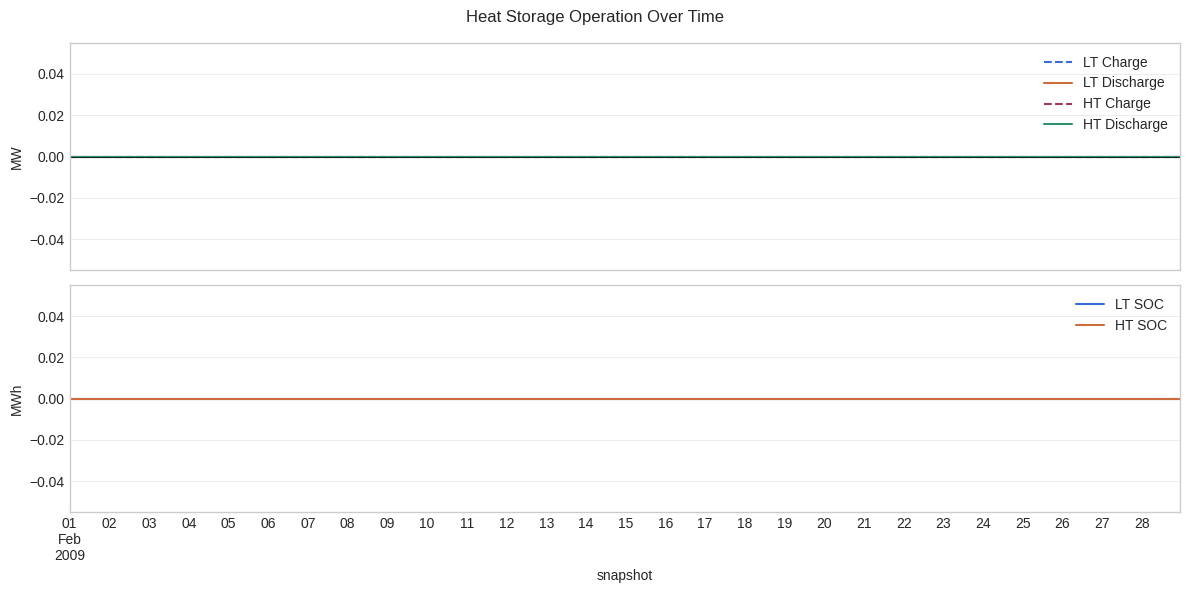

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# ── Charge / discharge ─────────────────────────────

# Low-temp heat
n.links_t.p0["heat_low_charge"].plot(
    ax=axes[0], label="LT Charge", linestyle="--"
)
(-n.links_t.p0["heat_low_discharge"]).plot(
    ax=axes[0], label="LT Discharge", linestyle="-"
)

# High-temp heat
n.links_t.p0["heat_high_charge"].plot(
    ax=axes[0], label="HT Charge", linestyle="--"
)
(-n.links_t.p0["heat_high_discharge"]).plot(
    ax=axes[0], label="HT Discharge", linestyle="-"
)

axes[0].set_ylabel("MW")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].legend()
axes[0].grid(True)

# ── State of charge ─────────────────────────────

n.stores_t.e["heat_low_storage"].plot(
    ax=axes[1], label="LT SOC"
)
n.stores_t.e["heat_high_storage"].plot(
    ax=axes[1], label="HT SOC"
)

axes[1].set_ylabel("MWh")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Heat Storage Operation Over Time")
plt.tight_layout()
plt.show()

Total curtailment: 2731.1 MWh
Wind curtailment: 2552.5 MWh
Solar curtailment: 178.7 MWh
Total wind generation [MWh]: 9856.043635451446
Total solar generation [MWh]: 678.5004537338879


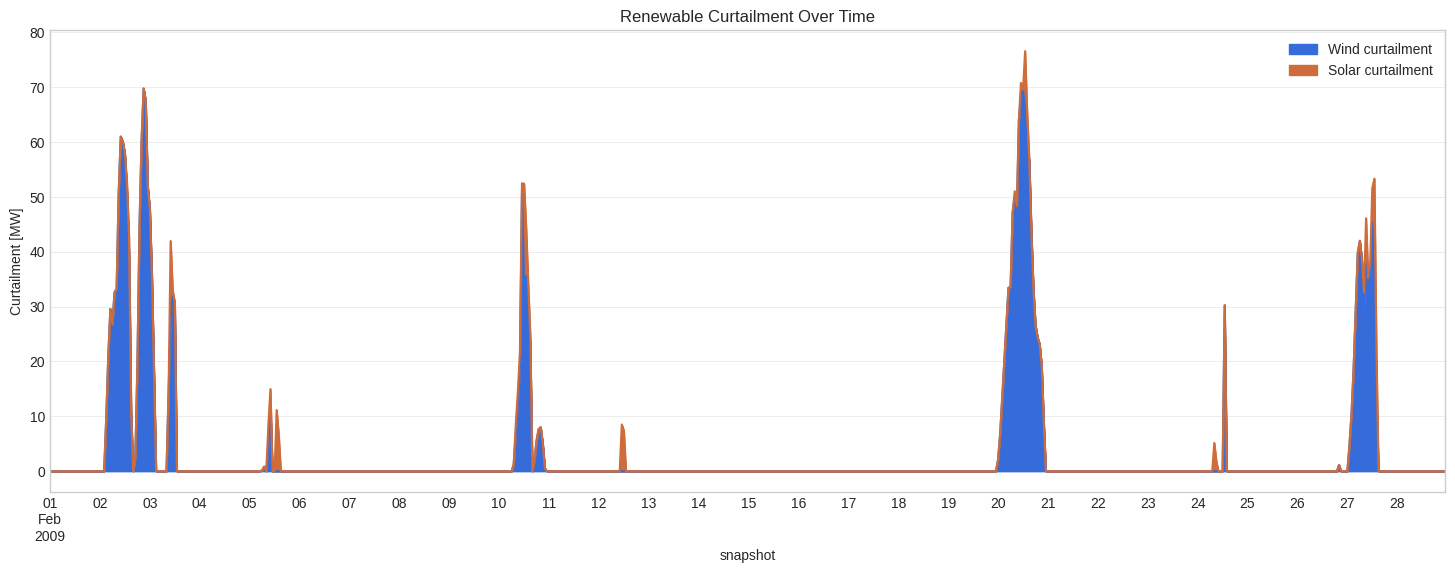

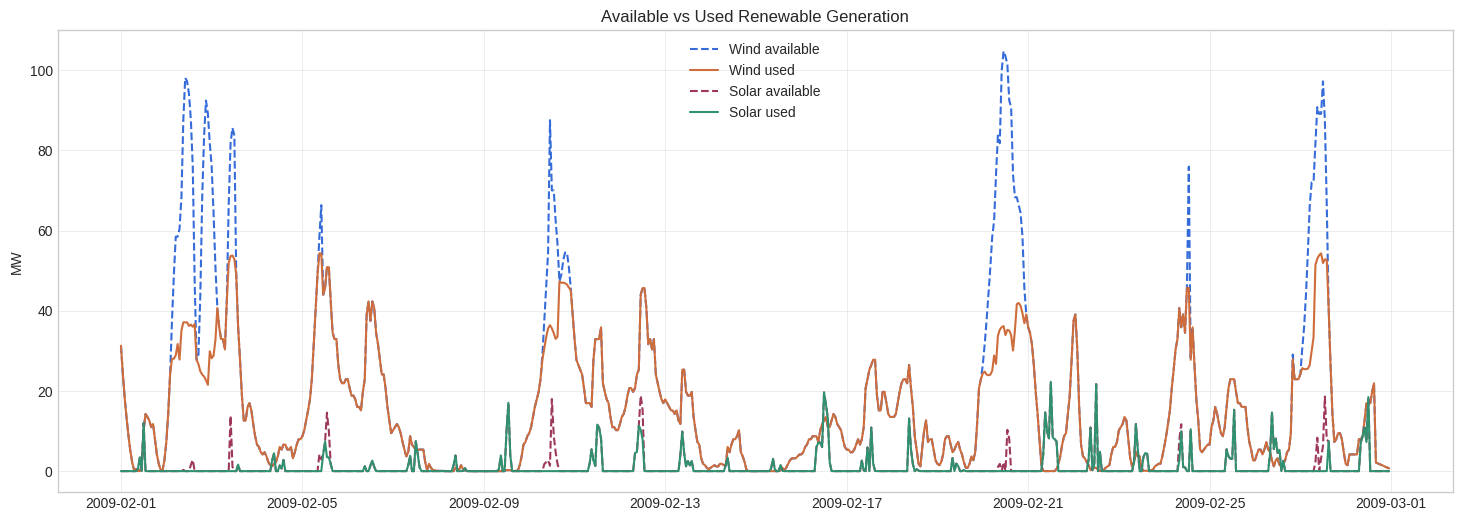

In [28]:
# Available generation (MW)
opt_wind_mw = n.generators.p_nom_opt["wind_zone1"] * n.generators_t.p_max_pu["wind_zone1"]
opt_solar_mw = n.generators.p_nom_opt["solar_zone1"] * n.generators_t.p_max_pu["solar_zone1"]

# Actual generation (MW)
gen_wind = n.generators_t.p["wind_zone1"]
gen_solar = n.generators_t.p["solar_zone1"]

# Curtailment (MW)
curtailment_wind = opt_wind_mw - gen_wind
curtailment_solar = opt_solar_mw - gen_solar

# Clean numerical noise
curtailment_wind = curtailment_wind.clip(lower=0)
curtailment_solar = curtailment_solar.clip(lower=0)

total_curtailment = (curtailment_wind + curtailment_solar).sum()

print(f"Total curtailment: {total_curtailment:.1f} MWh")
print(f"Wind curtailment: {curtailment_wind.sum():.1f} MWh")
print(f"Solar curtailment: {curtailment_solar.sum():.1f} MWh")

print("Total wind generation [MWh]:", gen_wind.sum())
print("Total solar generation [MWh]:", gen_solar.sum())

curtailment_df = pd.DataFrame({
    "Wind curtailment": curtailment_wind,
    "Solar curtailment": curtailment_solar
})

curtailment_df.plot.area(figsize=(18,6))
plt.ylabel("Curtailment [MW]")
plt.title("Renewable Curtailment Over Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(18,6))

plt.plot(opt_wind_mw, label="Wind available", linestyle="--")
plt.plot(gen_wind, label="Wind used")

plt.plot(opt_solar_mw, label="Solar available", linestyle="--")
plt.plot(gen_solar, label="Solar used")

plt.legend()
plt.title("Available vs Used Renewable Generation")
plt.ylabel("MW")
plt.grid(True)
plt.show()

Zone 2 has the new LT electricity demand from heat pumps — a battery at zone 1 helps generation-side but must still flow through the L12 link to serve zone 2. This is a valid design choice but worth discussing: a zone 2 battery would directly buffer heat pump demand peaks without congesting the line

In [29]:
n.export_to_netcdf("results/scenario_2F.nc")

INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'results/scenario_2F.nc contains: generators, links, buses, loads, stores, carriers, storage_units, sub_networks


<xarray.Dataset> Size: 304kB
Dimensions:                                (snapshots: 672, generators_i: 8,
                                            generators_t_p_max_pu_i: 3,
                                            generators_t_p_i: 6, links_i: 10,
                                            links_t_p0_i: 6, links_t_p1_i: 6,
                                            buses_i: 9, buses_t_p_i: 7,
                                            buses_t_marginal_price_i: 9,
                                            ...
                                            carriers_i: 15, storage_units_i: 1,
                                            storage_units_t_p_i: 1,
                                            storage_units_t_p_dispatch_i: 1,
                                            storage_units_t_p_store_i: 1,
                                            storage_units_t_state_of_charge_i: 1,
                                            sub_networks_i: 9)
Coordinates: (12/23)
  * snapshots                              (snapshots) int64 5kB 0 1 ... 670 671
  * generators_i                           (generators_i) object 64B 'solar_z...
  * generators_t_p_max_pu_i                (generators_t_p_max_pu_i) object 24B ...
  * generators_t_p_i                       (generators_t_p_i) object 48B 'sol...
  * links_i                                (links_i) object 80B 'h2_charge_zo...
  * links_t_p0_i                           (links_t_p0_i) object 48B 'h2_char...
    ...                                     ...
  * storage_units_i                        (storage_units_i) object 8B 'batte...
  * storage_units_t_p_i                    (storage_units_t_p_i) object 8B 'b...
  * storage_units_t_p_dispatch_i           (storage_units_t_p_dispatch_i) object 8B ...
  * storage_units_t_p_store_i              (storage_units_t_p_store_i) object 8B ...
  * storage_units_t_state_of_charge_i      (storage_units_t_state_of_charge_i) object 8B ...
  * sub_networks_i                         (sub_networks_i) object 72B '0' .....
Data variables: (12/68)
    snapshots_snapshot                     (snapshots) datetime64[ns] 5kB 200...
    snapshots_objective                    (snapshots) float64 5kB 1.0 ... 1.0
    snapshots_stores                       (snapshots) float64 5kB 1.0 ... 1.0
    snapshots_generators                   (snapshots) float64 5kB 1.0 ... 1.0
    generators_bus                         (generators_i) object 64B 'zone1_e...
    generators_control                     (generators_i) object 64B 'Slack' ...
    ...                                     ...
    storage_units_t_p_dispatch             (snapshots, storage_units_t_p_dispatch_i) float64 5kB ...
    storage_units_t_p_store                (snapshots, storage_units_t_p_store_i) float64 5kB ...
    storage_units_t_state_of_charge        (snapshots, storage_units_t_state_of_charge_i) float64 5kB ...
    sub_networks_carrier                   (sub_networks_i) object 72B 'elect...
    sub_networks_slack_bus                 (sub_networks_i) object 72B 'zone1...
    sub_networks_obj                       (sub_networks_i) float64 72B nan ....
Attributes:
    network__linearized_uc:       0
    network__multi_invest:        0
    network__objective:           10602523.543002011
    network__objective_constant:  104418.56168625358
    network_name:                 Unnamed Network
    network_pypsa_version:        1.1.2
    network_srid:                 4326
    crs:                          {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Wor...
    meta:                         {}